In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, accuracy_score, recall_score, mean_squared_error, confusion_matrix


In [8]:
df = pd.read_csv("drug200.csv")
df.head(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [9]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [13]:
tdf = df["Drug"].value_counts().reset_index()

In [14]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


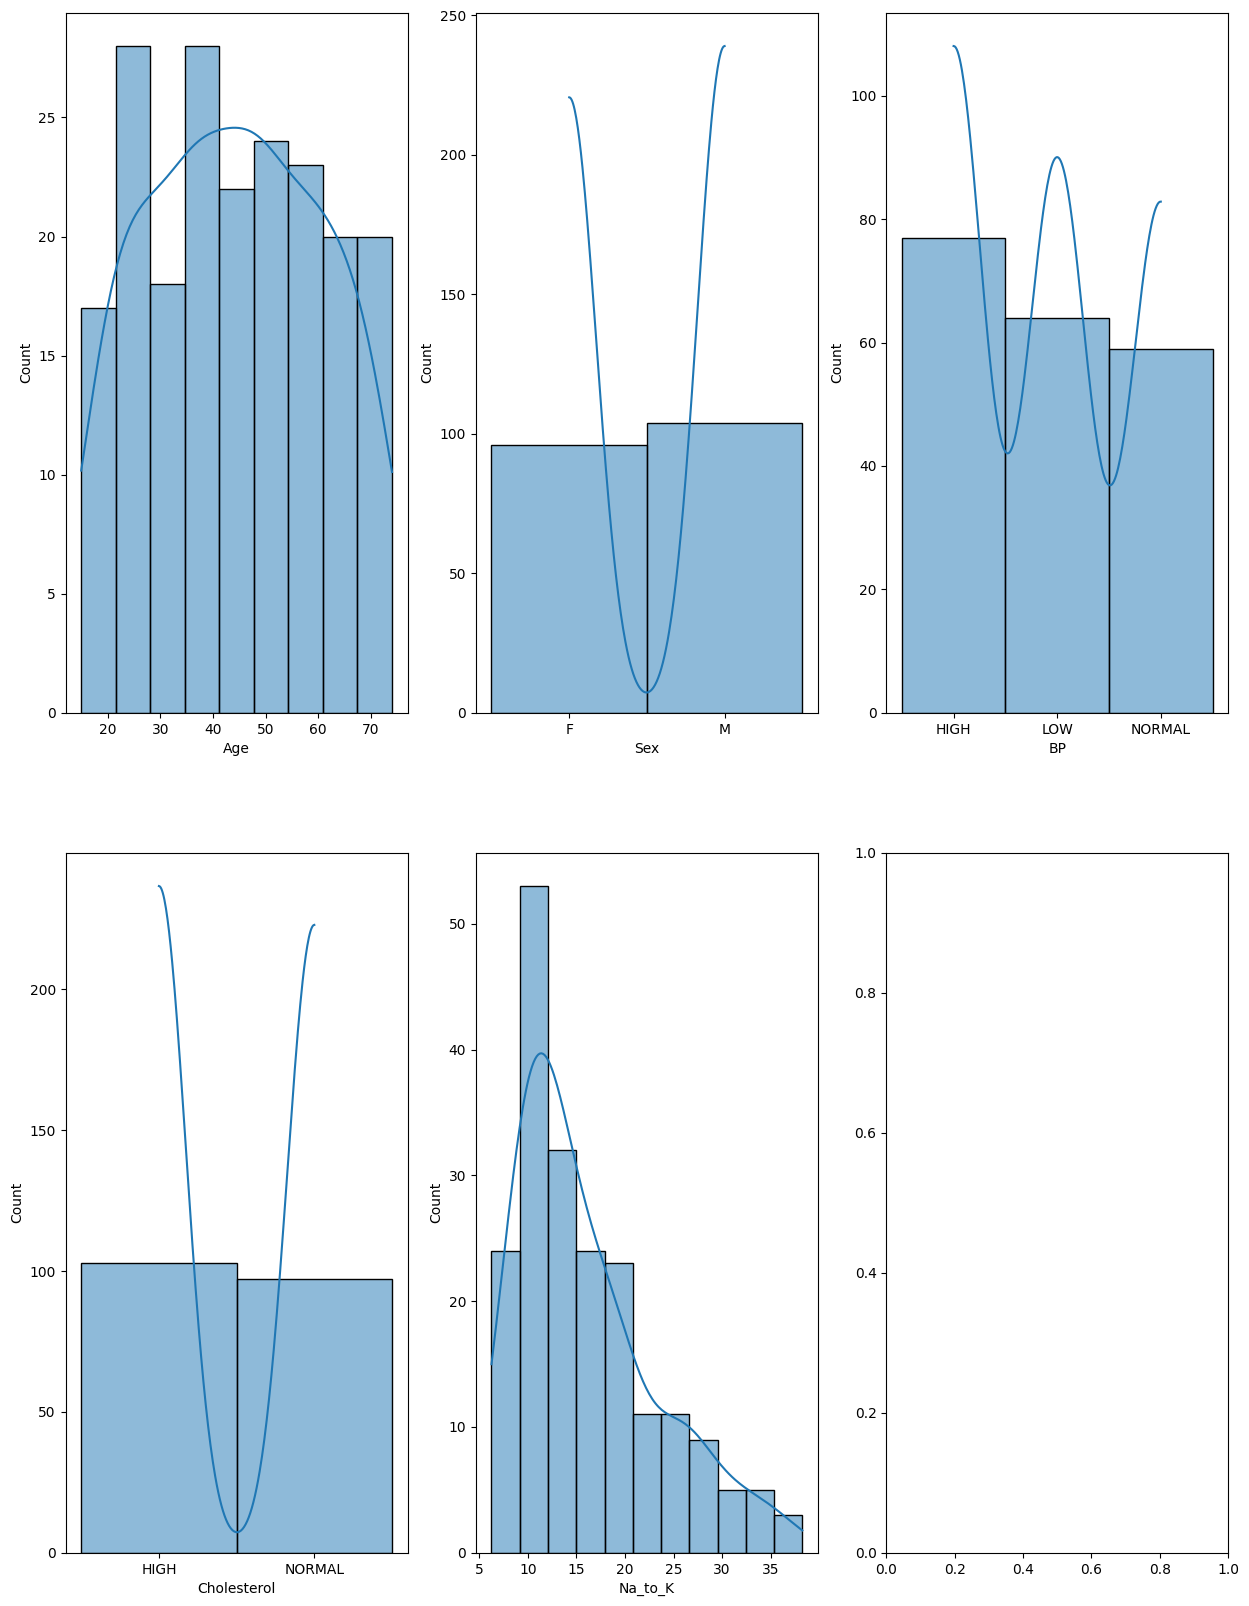

In [15]:
# Mengecek sebaran Data
fig,ax=plt.subplots(2,3,figsize=(15,20)) # 2x3 subplots
ax=ax.flatten()
i=0
for col in df.columns[df.columns!='Drug']:
    sns.histplot(data=df,x=col,ax=ax[i],kde=True)
    i+=1

In [16]:
## Memisahkan Numeric dan Categorical Features

numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns

C:\Users\user\AppData\Local\Temp\ipykernel_4560\2973109767.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [17]:
# # Checking Outliers Using Template Code
# ## Checking Outliers
# ## Karena Ini menyangkut terkait Hal Narkoba, outliersnya akan kita biarkan saja.

# import pandas as pd
# import math

# numeric_features = df.select_dtypes(include=['number']).columns
# categorical_features = df.select_dtypes(include=['object']).columns

# jumlah_fitur = len(numeric_features)

# # 2. Atur tata letak grid (misal: 3 kolom per baris)
# kolom_grid = 3
# baris_grid = math.ceil(jumlah_fitur / kolom_grid)

# # 3. Buat kanvas (figure) dan kotak-kotaknya (axes)
# # figsize diatur dinamis: lebar 15, tinggi menyesuaikan jumlah baris
# fig, axes = plt.subplots(baris_grid, kolom_grid, figsize=(15, 4 * baris_grid))
# axes = axes.flatten() # Ratakan array kotak agar mudah diisi pakai loop

# # 4. Looping untuk menggambar boxplot Seaborn ke dalam masing-masing kotak
# for i, col in enumerate(numeric_features):
#     sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
#     axes[i].set_title(f'Outliers: {col}', fontsize=12, fontweight='bold')
#     axes[i].set_ylabel('') # Sembunyikan label Y agar UI lebih bersih

# # 5. Hapus kotak sisa yang kosong (jika total fitur Anda bukan kelipatan 3)
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# # 6. Rapikan jarak antar kotak dan tampilkan
# plt.tight_layout()
# plt.show()

In [18]:
# # Cleaning Dataset
# ## MENGHAPUS NILAI OUTLIERS
# Q1 = df[numeric_features].quantile(0.25)
# Q3 = df[numeric_features].quantile(0.75)
# IQR = Q3 - Q1

# # Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
# condition = ~((df[numeric_features] < (Q1 - 1.5 * IQR)) | (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
# df_filtered_numeric = df.loc[condition, numeric_features]
 
# # Menggabungkan kembali dengan kolom kategorikal
# categorical_features = df.select_dtypes(include=['object']).columns
# df = pd.concat([df_filtered_numeric, df.loc[condition, categorical_features]], axis=1)

In [19]:
for column in categorical_features:
    print(df[column].value_counts().reset_index())

  Sex  count
0   M    104
1   F     96
       BP  count
0    HIGH     77
1     LOW     64
2  NORMAL     59
  Cholesterol  count
0        HIGH    103
1      NORMAL     97
    Drug  count
0  DrugY     91
1  drugX     54
2  drugA     23
3  drugC     16
4  drugB     16


In [20]:
df.head(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [21]:
## Saya barusan belajar mengenai OrdinalEncoder
## Jadi karena dataset BP dan Cholesterol fiturnya
# berurutan dari rendah ke tinggi, jadi kita gunakan ordinal encoder
# Separasi Fitur (X) dan Target (y)
X = df.drop("Drug", axis=1)
y = df["Drug"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [22]:

## Fitur Sex kita buat menggunakan OHE(One Hot Encoding)
## Fitur BP dan Cholesterol kita gunakan OrdinalEncoding
## Untuk FItur target gunakan LabelEncoder
OHE = OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)
label_encoder = LabelEncoder()

# Encoding fitur target dengan Label Encoder
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Encoding Fitur BP dan Cholestrol dengan OrdinalEncoding
# Urutkan dari yang terlemah, atau LOW(0) - NORMAL(1)- HIGH(2)
ord_order = [['LOW', 'NORMAL', 'HIGH'], ['NORMAL', 'HIGH']]
ord_encoder = OrdinalEncoder(categories=ord_order)

# Terapkan di Dataset train dan test
X_train[["BP", "Cholesterol"]] = ord_encoder.fit_transform(X_train[["BP", "Cholesterol"]])
X_test[["BP", "Cholesterol"]] = ord_encoder.transform(X_test[["BP", "Cholesterol"]])

# One Hot Encoding di fitur Sex (Karena dia nominal(tidak ada tingkatan dalam fiturnya))
X_train["Sex"] = OHE.fit_transform(X_train[["Sex"]]).ravel()
X_test["Sex"] = OHE.transform(X_test[["Sex"]]).ravel()

# X_train["Sex"] = sex_train
# X_test["Sex"] = sex_test


In [23]:
X_train["Sex"]

79     0.0
197    1.0
38     0.0
24     0.0
122    1.0
      ... 
106    1.0
14     0.0
92     0.0
179    0.0
102    0.0
Name: Sex, Length: 160, dtype: float64

In [24]:
for column in categorical_features:
    if column == "Drug":
        continue
    print(X_train[column].value_counts().reset_index())

   Sex  count
0  1.0     83
1  0.0     77
    BP  count
0  2.0     62
1  1.0     51
2  0.0     47
   Cholesterol  count
0          1.0     88
1          0.0     72


In [25]:
for column in categorical_features:
    if column != "Drug":
        print(X_train[column].value_counts().reset_index())

   Sex  count
0  1.0     83
1  0.0     77
    BP  count
0  2.0     62
1  1.0     51
2  0.0     47
   Cholesterol  count
0          1.0     88
1          0.0     72


In [26]:
## Applying SMOTE in Dataset
## Berfungsi untuk menyeimbangkan jumlah data target dalam dataset ini

from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto',random_state=42) # Balancing all classes equally

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(y_train_smote)
pd.Series(y_train_smote).value_counts()


[4 4 4 0 0 3 0 0 0 4 4 0 4 0 4 0 1 0 0 0 1 0 2 0 4 0 0 0 0 2 4 4 4 2 1 4 0
 4 1 4 3 0 1 1 1 2 2 1 0 1 0 0 1 0 0 0 4 0 4 0 0 4 2 4 0 1 3 0 4 4 0 0 4 4
 2 0 2 4 0 0 0 2 3 1 0 0 0 1 4 4 0 3 0 0 4 2 4 4 0 0 0 0 0 0 2 4 3 1 0 1 1
 4 0 0 0 0 4 0 1 4 0 0 4 0 4 2 0 0 3 4 0 0 0 0 4 0 4 4 0 3 3 0 3 0 2 4 0 4
 0 0 0 4 0 0 0 4 4 0 0 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4]


4    76
0    76
3    76
1    76
2    76
Name: count, dtype: int64

In [ ]:
## BELAJAR DULU PAKE KODE YANG OG
## Load model

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Model Initiation
dt_base = RandomForestClassifier(random_state=42)
rf_base = RandomForestClassifier(random_state=42)

## Model Training

dt_base.fit(X_train_smote, y_train_smote)
rf_base.fit(X_train_smote, y_train_smote)

## Prediksi data testing
y_pred_dt = dt_base.predict(X_test)
y_pred_rf = rf_base.predict(X_test)

print("------- Hasil Evaluasi Decision Tree -------")
print(classification_report(y_test, y_pred_dt))

print("----Hasil Evaluasi Model Random Forest-----")
print(classification_report(y_test, y_pred_rf))



------- Hasil Evaluasi Decision Tree -------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

----Hasil Evaluasi Model Random Forest-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.0

In [40]:
## Menggunakan GridSearch 
## Kita coba terapkan GridSearch dan CrossValidation dalam model random Forest
from sklearn.model_selection import GridSearchCV

# 1. Menentukan kombinasi parameter parameter apa yang ingin dicoba
rf_params = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 5, 10, 15],
    'min_samples_split' : [2, 5, 10]
}

# 2. Siapkan GridSearchnya atau bisa menggunakan randomsearch(Explore lagi!)
rf_grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42), 
    param_grid= rf_params,
    cv = 5, ## Menentukan berapa jumlah 
            ## cross validationnya(datanya dipecah ke 5x percobaan lalu dicari rata2 akurasinya)
    scoring='accuracy',
    n_jobs= -1 # Menggunakan semua core di CPU kita
) 

# Mulai pencarian Parameter terbaik dalam dataset training kita
print("Mulai Mencari parameter terbaik!...")
rf_grid.fit(X_train_smote, y_train_smote)

# Menampilkan parameter terbaik
print(f"parameter terbaik untuk model RF yaitu: {rf_grid.best_params_}")

# Menggunakan parameter terbaik untuk melatih model RF
best_params_rf = rf_grid.best_estimator_
y_pred_rf_grid = best_params_rf.predict(X_test)

# Evaluasi hasil training
print(classification_report(y_test, y_pred_rf_grid))


Mulai Mencari parameter terbaik!...
parameter terbaik untuk model RF yaitu: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [43]:
print(rf_grid.best_params_)
print(rf_grid.best_estimator_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
RandomForestClassifier(n_estimators=50, random_state=42)


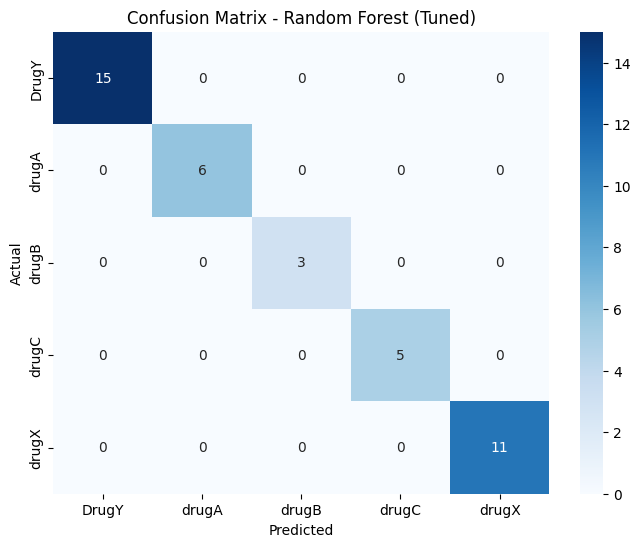

In [42]:
# Visualisasi Confusion Matrix untuk model yang sudah di-tuning
cm = confusion_matrix(y_test, y_pred_rf_grid)

plt.figure(figsize=(8, 6))
# Gunakan label encoder classes_ untuk nama obat asli
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()